In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
print(tf.__version__)

2.9.1


In [3]:
train_generator = ImageDataGenerator(rescale=1.0 / 255).flow_from_directory(
    '../dataset_resized_224x224/split_augmented/fold1/train',
    target_size=(224, 224),  # Resize images to a specific size
    batch_size=8,  # Set the batch size based on your hardware capabilities
    class_mode='categorical',  # Specify the type of classification task
    shuffle=True  # Shuffle the data for better training
)

test_generator = ImageDataGenerator(rescale=1.0 / 255).flow_from_directory(
    '../dataset_resized_224x224/split_augmented/fold1/test',
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical',
    shuffle=False  # Don't shuffle the test data
)

val_generator = ImageDataGenerator(rescale=1.0 / 255).flow_from_directory(
    '../dataset_resized_224x224/split_augmented/fold1/val',
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical',
    shuffle=True  # Don't shuffle the test data
)

Found 8040 images belonging to 3 classes.
Found 252 images belonging to 3 classes.
Found 402 images belonging to 3 classes.


In [4]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(3, activation='softmax')  # 3 classes (healthy, caterpillar, leafspot)
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 111, 111, 32)     0         
 )                                                               
                                                                 
 flatten (Flatten)           (None, 394272)            0         
                                                                 
 dense (Dense)               (None, 3)                 1182819   
                                                                 
Total params: 1,183,715
Trainable params: 1,183,715
Non-trainable params: 0
_________________________________________________________________


In [7]:
# Define early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    verbose=1,
    restore_best_weights=True
)

In [8]:
# Train the model using the train_generator and add the early stopping callback
history = model.fit(
    train_generator,
    epochs=100,
    validation_data=val_generator,
    callbacks=[early_stopping]
)

Epoch 1/100
1005/1005 [==============================] - 82s 81ms/step - loss: 0.5142 - accuracy: 0.8735 - val_loss: 1.0292 - val_accuracy: 0.7264
Epoch 2/100
1005/1005 [==============================] - 86s 86ms/step - loss: 0.0341 - accuracy: 0.9919 - val_loss: 2.0603 - val_accuracy: 0.5572
Epoch 3/100
1005/1005 [==============================] - 73s 72ms/step - loss: 0.0534 - accuracy: 0.9845 - val_loss: 1.5839 - val_accuracy: 0.7090
Epoch 4/100
1005/1005 [==============================] - 69s 69ms/step - loss: 0.0034 - accuracy: 0.9998 - val_loss: 1.6980 - val_accuracy: 0.6816
Epoch 5/100
1005/1005 [==============================] - 65s 65ms/step - loss: 0.0221 - accuracy: 0.9945 - val_loss: 2.1769 - val_accuracy: 0.6940
Epoch 6/100
1005/1005 [==============================] - 63s 63ms/step - loss: 0.0476 - accuracy: 0.9866 - val_loss: 2.6600 - val_accuracy: 0.6592
Epoch 6: early stopping


32/32 [==============================] - 2s 61ms/step
Classification Report:
              precision    recall  f1-score   support

 caterpillar   0.905882  0.777778  0.836957        99
     healthy   0.698795  0.716049  0.707317        81
    leafspot   0.726190  0.847222  0.782051        72

    accuracy                       0.777778       252
   macro avg   0.776956  0.780350  0.775442       252
weighted avg   0.787978  0.777778  0.779599       252



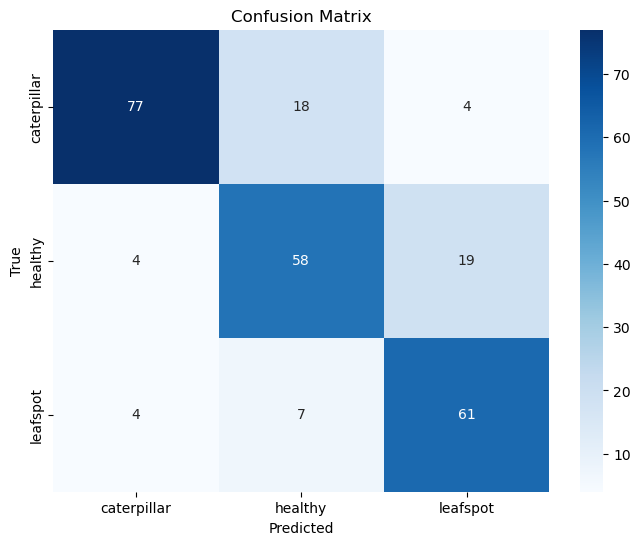

In [9]:
# Evaluate the model on the test data
test_results = model.evaluate(test_generator)
# Make predictions on the test data
y_pred = model.predict(test_generator)
# Convert one-hot encoded labels back to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Get the actual class labels from the test generator
y_true = test_generator.classes

# Generate the classification report
class_report = classification_report(y_true, y_pred_classes, target_names=test_generator.class_indices.keys(), digits=6)

print("Classification Report:")
print(class_report)

# Generate the confusion matrix
confusion_mat = confusion_matrix(y_true, y_pred_classes)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_mat, annot=True, fmt="d", cmap="Blues", xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()